In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
data = pd.read_csv('../dataset/processed/battery_health_dataset.csv')

X = data[['Voltage_measured', 'Current_measured', 'Temperature_measured', 'SoC', 'cycle_number']]
y = data['SoH']

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Initialize the model
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVR, OneClassSVM
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error


models = {
    'Random Forest': RandomForestRegressor(random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
}

In [5]:
# Define hyperparameter grids
param_grids = {
    'Random Forest': {
        'n_estimators': [50, 100, 120],
        'max_depth': [None, 10, 15],
        'min_samples_split': list(range(2, 6)),
        'min_samples_leaf': list(range(1, 4))
    },
    'XGBoost': {
        'n_estimators': [50, 100, 200],
        'max_depth': list(range(3, 10)),
        'learning_rate': [0.01, 0.1, 0.25],
        'subsample': [0.7, 1.0],
        'colsample_bytree': [0.7, 1.0]
    },
    'Decision Tree': {
        'max_depth': [None, 10, 15],
        'min_samples_split': list(range(2, 6)),
        'min_samples_leaf': list(range(1, 6))
    }
}

In [6]:
best_models = {}
best_scores = {}

# Run GridSearchCV for each model
for model_name, model in models.items():
    print(f"Running GridSearchCV for {model_name}...")

    grid_search = GridSearchCV(
        model, 
        param_grid=param_grids[model_name],
        cv=5,
        scoring='neg_root_mean_squared_error',  # RMSE as metric
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    best_models[model_name] = grid_search.best_estimator_
    best_scores[model_name] = -grid_search.best_score_

    print(f"Best {model_name}: {grid_search.best_params_}")
    print(f"Best RMSE: {best_scores[model_name]:.4f}\n")

Running GridSearchCV for Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best RMSE: 1.3948

Running GridSearchCV for Decision Tree...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Decision Tree: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best RMSE: 1.7968

Running GridSearchCV for XGBoost...
Fitting 5 folds for each of 252 candidates, totalling 1260 fits


c:\Users\HLC\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best XGBoost: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 200, 'subsample': 0.7}
Best RMSE: 1.1139



In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Store final results
final_results = {}

# Test each best model on the test set
for model_name, best_model in best_models.items():
    y_pred = best_model.predict(X_test)

    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    final_results[model_name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}

# Display results
print(f"{'Model':<20}{'MAE':<10}{'RMSE':<10}{'R² Score':<10}")
print("="*50)
for model_name, metrics in final_results.items():
    print(f"{model_name:<20}{metrics['MAE']:<10.4f}{metrics['RMSE']:<10.4f}{metrics['R²']:<10.4f}")

Model               MAE       RMSE      R² Score  
Random Forest       0.4787    1.3987    0.9609    
Decision Tree       0.4901    1.6525    0.9454    
XGBoost             0.5218    1.1879    0.9718    


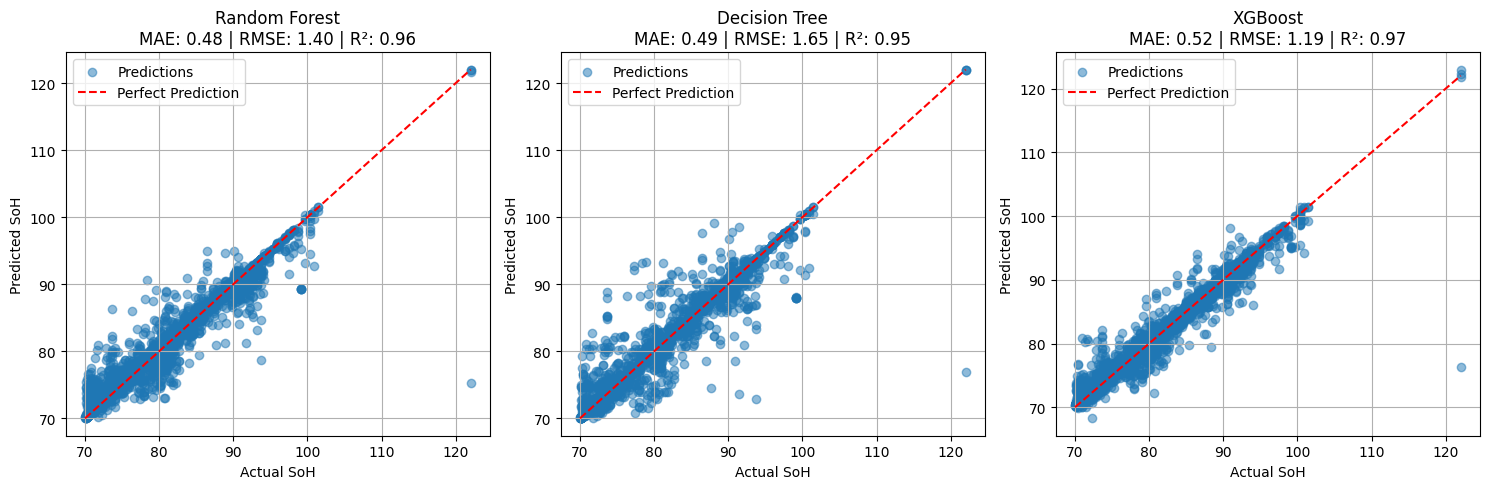

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for i, (model_name, model) in enumerate(best_models.items()):
    y_pred = model.predict(X_test)
    
    ax = axes[i]
    ax.scatter(y_test, y_pred, alpha=0.5, label='Predictions')
    ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 
            color='red', linestyle='--', label='Perfect Prediction')
    
    ax.set_xlabel('Actual SoH')
    ax.set_ylabel('Predicted SoH')
    ax.set_title(f'{model_name}\nMAE: {final_results[model_name]["MAE"]:.2f} | '
                 f'RMSE: {final_results[model_name]["RMSE"]:.2f} | R²: {final_results[model_name]["R²"]:.2f}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

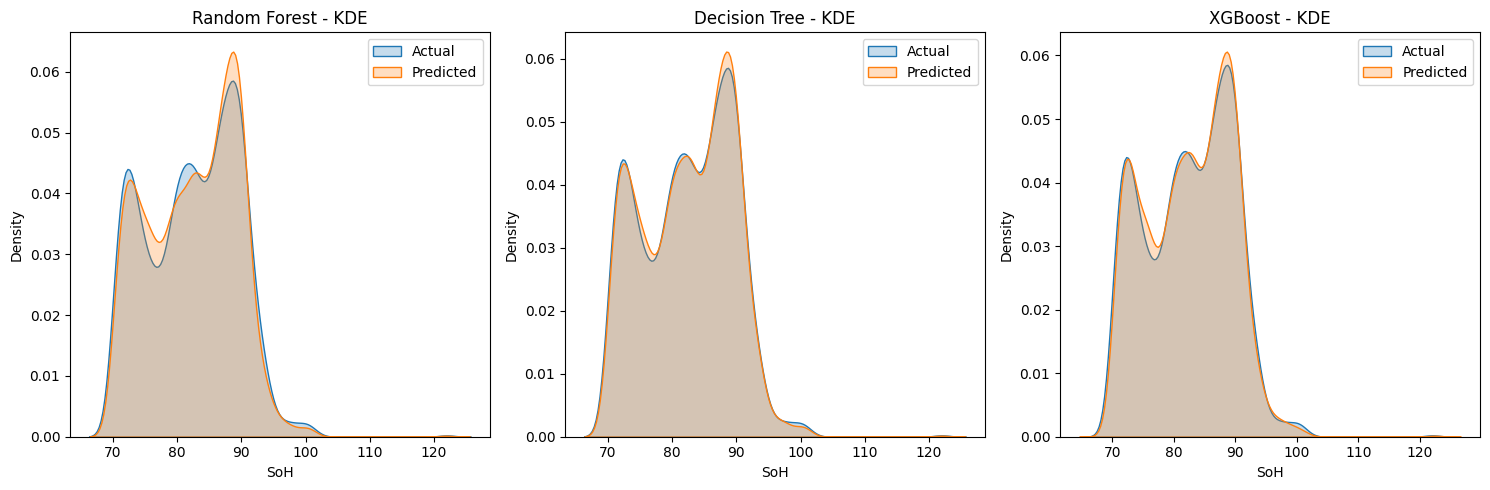

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for i, (model_name, model) in enumerate(best_models.items()):
    y_pred = model.predict(X_test)

    sns.kdeplot(y_test, label='Actual', ax=axes[i], fill=True)
    sns.kdeplot(y_pred, label='Predicted', ax=axes[i], fill=True)

    axes[i].set_title(f'{model_name} - KDE')
    axes[i].set_xlabel('SoH')
    axes[i].legend()

plt.tight_layout()
plt.show()